In [1]:
import sys
sys.path.append('../Scripts')

In [2]:
from data import LoadData
import numpy as np
import pandas as pd
import requests
import glob
from pathlib import Path

In [3]:
data_loader = LoadData(source_data_path='data/')

In [4]:
nation_data = data_loader.get_uk_df(area_type="nation", filename="../data/raw/nation_data.csv", min_confirmed=1)
nation_data.head()

,areaName,date,areaCode,dailyCases,cumulativeCases
0,England,2023-11-08,E92000001,388,21000649
1,England,2023-11-07,E92000001,681,21000261
2,England,2023-11-06,E92000001,740,20999580
3,England,2023-11-05,E92000001,656,20998840
4,England,2023-11-04,E92000001,578,20998184


In [5]:
utla_data = data_loader.get_uk_df(area_type="utla", filename="../data/raw/utla_data.csv", min_confirmed=2)
utla_data.head()

,areaName,date,areaCode,dailyCases,cumulativeCases
0,Wokingham,2023-11-07,E06000041,3,68069
1,Wokingham,2023-11-06,E06000041,1,68066
2,Wokingham,2023-11-05,E06000041,2,68065
3,Wokingham,2023-11-04,E06000041,1,68063
4,Wokingham,2023-11-03,E06000041,2,68062


In [6]:
ltla_data = data_loader.get_uk_df(area_type="ltla", filename="../data/raw/ltla_data.csv", min_confirmed=2)
ltla_data.head()

,areaName,date,areaCode,dailyCases,cumulativeCases
0,South Gloucestershire,2023-11-07,E06000025,2,111152
1,South Gloucestershire,2023-11-06,E06000025,5,111150
2,South Gloucestershire,2023-11-05,E06000025,5,111145
3,South Gloucestershire,2023-11-04,E06000025,4,111140
4,South Gloucestershire,2023-11-03,E06000025,5,111136


In [7]:
region_data = data_loader.get_uk_df(area_type="region", filename="../data/raw/region_data.csv", min_confirmed=2)
region_data.head()

,areaName,date,areaCode,dailyCases,cumulativeCases
0,North West,2023-11-07,E12000002,46,2866182
1,North West,2023-11-06,E12000002,104,2866136
2,North West,2023-11-05,E12000002,71,2866032
3,North West,2023-11-04,E12000002,71,2865961
4,North West,2023-11-03,E12000002,93,2865890


In [8]:
data_loader.merge_dataframes(
    covid_data_path="../data/raw/nation_data.csv",
    covid_graph_path="../data/raw/Countries_Dec_2021_GB_BFC_2022_-3032294030278234928.csv",
    population_data_path="../data/raw/population.csv",
    output_file_name="../data/interim/merged_Nationdata.csv",
    column="CTRY21CD"
)

In [9]:
data_loader.merge_dataframes(
    covid_data_path="../data/raw/ltla_data.csv",
    covid_graph_path="../data/raw/Local_Authority_Districts_December_2022_Boundaries_UK_BFC_-4691976587153824100.csv",
    population_data_path="../data/raw/population.csv",
    output_file_name="../data/interim/merged_LTLA_data.csv",
    column="LAD22CD"
)


In [10]:
nation_data = pd.read_csv("../data/interim/merged_Nationdata.csv")
nation_data.head()

,areaName,date,areaCode,dailyCases,cumulativeCases,population,long,lat
0,England,2023-11-08,E92000001,388,21000649,"56,536,419",-2.07811,53.235
1,England,2023-11-07,E92000001,681,21000261,"56,536,419",-2.07811,53.235
2,England,2023-11-06,E92000001,740,20999580,"56,536,419",-2.07811,53.235
3,England,2023-11-05,E92000001,656,20998840,"56,536,419",-2.07811,53.235
4,England,2023-11-04,E92000001,578,20998184,"56,536,419",-2.07811,53.235


In [11]:
# Find rows with missing values
missing_values = nation_data[nation_data.isnull().any(axis=1)]

# Print the rows with missing values
missing_values

,areaName,date,areaCode,dailyCases,cumulativeCases,population,long,lat
1379,Northern Ireland,2022-05-19,N92000002,190,713294,"1,904,563",NaN,NaN
1380,Northern Ireland,2022-05-18,N92000002,266,713104,"1,904,563",NaN,NaN
1381,Northern Ireland,2022-05-17,N92000002,318,712838,"1,904,563",NaN,NaN
1382,Northern Ireland,2022-05-16,N92000002,356,712520,"1,904,563",NaN,NaN
1383,Northern Ireland,2022-05-15,N92000002,281,712164,"1,904,563",NaN,NaN
...,...,...,...,...,...,...,...,...
2188,Northern Ireland,2020-03-01,N92000002,0,1,"1,904,563",NaN,NaN
2189,Northern Ireland,2020-02-29,N92000002,0,1,"1,904,563",NaN,NaN
2190,Northern Ireland,2020-02-28,N92000002,0,1,"1,904,563",NaN,NaN
2191,Northern Ireland,2020-02-27,N92000002,0,1,"1,904,563",NaN,NaN


In [12]:
nation_data.loc[nation_data['areaName'] == 'Northern Ireland', ['long', 'lat']] = [-6.49231, 54.7877]
nation_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4856 entries, 0 to 4855
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   areaName         4856 non-null   object 
 1   date             4856 non-null   object 
 2   areaCode         4856 non-null   object 
 3   dailyCases       4856 non-null   int64  
 4   cumulativeCases  4856 non-null   int64  
 5   population       4856 non-null   object 
 6   long             4856 non-null   float64
 7   lat              4856 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 303.6+ KB


In [13]:
min_dates = nation_data.groupby("areaName")["date"].min()
print(min_dates)

areaName
England             2020-01-30
Northern Ireland    2020-02-26
Scotland            2020-02-28
Wales               2020-02-27
Name: date, dtype: object


In [14]:
nation_data.to_csv("../data/processed/merged_Nationdata.csv")

In [15]:
ltla_data = pd.read_csv("../data/interim/merged_LTLA_data.csv")
ltla_data.head()

,areaName,date,areaCode,dailyCases,cumulativeCases,population,long,lat
0,South Gloucestershire,2023-11-07,E06000025,2,111152,"290,736",-2.46922,51.54673
1,South Gloucestershire,2023-11-06,E06000025,5,111150,"290,736",-2.46922,51.54673
2,South Gloucestershire,2023-11-05,E06000025,5,111145,"290,736",-2.46922,51.54673
3,South Gloucestershire,2023-11-04,E06000025,4,111140,"290,736",-2.46922,51.54673
4,South Gloucestershire,2023-11-03,E06000025,5,111136,"290,736",-2.46922,51.54673


In [16]:
ltla_data.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502612 entries, 0 to 502611
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   areaName         502612 non-null  object 
 1   date             502612 non-null  object 
 2   areaCode         502612 non-null  object 
 3   dailyCases       502612 non-null  int64  
 4   cumulativeCases  502612 non-null  int64  
 5   population       487870 non-null  object 
 6   long             487870 non-null  float64
 7   lat              487870 non-null  float64
dtypes: float64(2), int64(2), object(4)
memory usage: 30.7+ MB


In [17]:
# Find rows with missing values
missing_values = ltla_data[ltla_data.isnull().any(axis=1)]

# Print the rows with missing values
missing_values

,areaName,date,areaCode,dailyCases,cumulativeCases,population,long,lat
7513,Aylesbury Vale,2023-11-07,E07000004,1,76431,NaN,NaN,NaN
7514,Aylesbury Vale,2023-11-06,E07000004,1,76430,NaN,NaN,NaN
7515,Aylesbury Vale,2023-11-05,E07000004,4,76429,NaN,NaN,NaN
7516,Aylesbury Vale,2023-11-04,E07000004,0,76425,NaN,NaN,NaN
7517,Aylesbury Vale,2023-11-03,E07000004,2,76425,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
483923,Chiltern,2020-03-13,E07000005,1,10,NaN,NaN,NaN
483924,Chiltern,2020-03-12,E07000005,4,9,NaN,NaN,NaN
483925,Chiltern,2020-03-11,E07000005,2,5,NaN,NaN,NaN
483926,Chiltern,2020-03-10,E07000005,2,3,NaN,NaN,NaN


In [18]:
urls = [
    "https://api.coronavirus.data.gov.uk/v2/data?areaType=nhsRegion&areaCode=E40000007&metric=covidOccupiedMVBeds&metric=hospitalCases&metric=newAdmissions&metric=cumAdmissions&format=csv",
    "https://api.coronavirus.data.gov.uk/v2/data?areaType=nhsRegion&areaCode=E40000003&metric=covidOccupiedMVBeds&metric=hospitalCases&metric=newAdmissions&metric=cumAdmissions&format=csv",
    "https://api.coronavirus.data.gov.uk/v2/data?areaType=nhsRegion&areaCode=E40000008&metric=covidOccupiedMVBeds&metric=hospitalCases&metric=newAdmissions&metric=cumAdmissions&format=csv",
    "https://api.coronavirus.data.gov.uk/v2/data?areaType=nhsRegion&areaCode=E40000009&metric=covidOccupiedMVBeds&metric=hospitalCases&metric=newAdmissions&metric=cumAdmissions&format=csv",
    "https://api.coronavirus.data.gov.uk/v2/data?areaType=nhsRegion&areaCode=E40000010&metric=covidOccupiedMVBeds&metric=hospitalCases&metric=newAdmissions&metric=cumAdmissions&format=csv",
    "https://api.coronavirus.data.gov.uk/v2/data?areaType=nhsRegion&areaCode=E40000005&metric=covidOccupiedMVBeds&metric=hospitalCases&metric=newAdmissions&metric=cumAdmissions&format=csv",
    "https://api.coronavirus.data.gov.uk/v2/data?areaType=nhsRegion&areaCode=E40000006&metric=covidOccupiedMVBeds&metric=hospitalCases&metric=newAdmissions&metric=cumAdmissions&format=csv"
]
source_data = Path("../data/")

In [19]:
for idx, url in enumerate(urls, start=1):
    response = requests.get(url)

    if response.status_code == 200:
        content = response.content
        # Save the content to a CSV file
        filename = source_data/f"raw/NHS_region/covid_data_{idx}.csv"
        with open(filename, "wb") as csv_file:
            csv_file.write(content)
        print(f"Data from URL {idx} saved as '{filename}'")
    else:
        print(f"Failed to retrieve data from URL {idx}")

Data from URL 1 saved as '..\data\raw\NHS_region\covid_data_1.csv'
Data from URL 2 saved as '..\data\raw\NHS_region\covid_data_2.csv'
Data from URL 3 saved as '..\data\raw\NHS_region\covid_data_3.csv'
Data from URL 4 saved as '..\data\raw\NHS_region\covid_data_4.csv'
Data from URL 5 saved as '..\data\raw\NHS_region\covid_data_5.csv'
Data from URL 6 saved as '..\data\raw\NHS_region\covid_data_6.csv'
Data from URL 7 saved as '..\data\raw\NHS_region\covid_data_7.csv'


In [20]:
def combine_csv_files(directory_path):
    """
    Combine all CSVs in a specified directory into a single DataFrame.

    :param directory_path: str
        Path to the directory containing the CSV files.

    :return: pd.DataFrame
        Combined data from all CSVs in one DataFrame.
    """

    # Convert the directory path to a Path object and resolve the pattern for CSV files
    csv_files_pattern = Path(directory_path) / 'raw/NHS_region/covid_data*.csv'

    # List all CSV files in the directory
    csv_files = glob.glob(str(csv_files_pattern))

    # Initialize an empty list to store DataFrames
    dfs = []

    # Loop through each CSV file and read it into a DataFrame
    for file in csv_files:
        df = pd.read_csv(file)
        dfs.append(df)

    # Concatenate the list of DataFrames into a single DataFrame
    if dfs:  # Proceed if the list is not empty
        combined_df = pd.concat(dfs, ignore_index=True)
        return combined_df
    else:
        print("No CSV files found in the specified directory.")
        return pd.DataFrame()

In [21]:
combined_df = combine_csv_files('../data/')
combined_df.head()

,areaCode,areaName,areaType,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions
0,E40000007,East of England,nhsRegion,2023-11-03,NaN,110847,318.0,35
1,E40000007,East of England,nhsRegion,2023-11-02,NaN,110812,329.0,45
2,E40000007,East of England,nhsRegion,2023-11-01,NaN,110767,342.0,47
3,E40000007,East of England,nhsRegion,2023-10-31,NaN,110720,345.0,43
4,E40000007,East of England,nhsRegion,2023-10-30,NaN,110677,368.0,40


In [22]:
combined_df.tail()

,areaCode,areaName,areaType,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions
9270,E40000006,South West,nhsRegion,2020-03-23,NaN,214,146.0,62
9271,E40000006,South West,nhsRegion,2020-03-22,NaN,152,140.0,37
9272,E40000006,South West,nhsRegion,2020-03-21,NaN,115,100.0,43
9273,E40000006,South West,nhsRegion,2020-03-20,NaN,72,62.0,43
9274,E40000006,South West,nhsRegion,2020-03-19,NaN,29,NaN,29


In [23]:
combined_df.covidOccupiedMVBeds.fillna(0, inplace=True)

In [24]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9275 entries, 0 to 9274
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   areaCode             9275 non-null   object 
 1   areaName             9275 non-null   object 
 2   areaType             9275 non-null   object 
 3   date                 9275 non-null   object 
 4   covidOccupiedMVBeds  9275 non-null   float64
 5   cumAdmissions        9275 non-null   int64  
 6   hospitalCases        9268 non-null   float64
 7   newAdmissions        9275 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 579.8+ KB


In [25]:
combined_df.head()

,areaCode,areaName,areaType,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions
0,E40000007,East of England,nhsRegion,2023-11-03,0.0,110847,318.0,35
1,E40000007,East of England,nhsRegion,2023-11-02,0.0,110812,329.0,45
2,E40000007,East of England,nhsRegion,2023-11-01,0.0,110767,342.0,47
3,E40000007,East of England,nhsRegion,2023-10-31,0.0,110720,345.0,43
4,E40000007,East of England,nhsRegion,2023-10-30,0.0,110677,368.0,40


<Axes: >

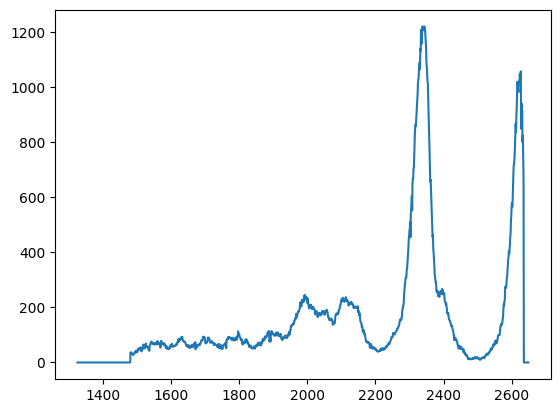

In [26]:
# Filter the DataFrame and plot
combined_df[combined_df["areaName"] == "London"].covidOccupiedMVBeds.plot()


In [27]:
start_date = pd.to_datetime('2020-04-02')  
end_date = pd.to_datetime('2023-05-31')  

combined_df['date'] = pd.to_datetime(combined_df['date'])

filtered_df = combined_df[
    (combined_df['date'] >= start_date) &
    (combined_df['date'] <= end_date) &
    (~combined_df['covidOccupiedMVBeds'].isna())
]

# Save the filtered DataFrame to a CSV file
filtered_df.to_csv(source_data/"raw/NHS_region/filtered_data.csv")
print("Filtered data saved as 'filtered_data.csv'")

Filtered data saved as 'filtered_data.csv'


In [28]:
aggreate_data = filtered_df.groupby("date").agg({
    'covidOccupiedMVBeds': 'sum',
    'cumAdmissions': 'sum',
    'hospitalCases': 'sum',
    'newAdmissions': 'sum'
}).reset_index()

aggreate_data.head()

,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions
0,2020-04-02,1494.0,26264,12135.0,2932
1,2020-04-03,1788.0,28828,13635.0,2564
2,2020-04-04,1950.0,31421,15469.0,2593
3,2020-04-05,2097.0,34013,16657.0,2592
4,2020-04-06,2264.0,36692,17154.0,2679


In [29]:
nation_data = nation_data[nation_data["areaName"].str.contains('England')]
nation_data.head()

,areaName,date,areaCode,dailyCases,cumulativeCases,population,long,lat
0,England,2023-11-08,E92000001,388,21000649,"56,536,419",-2.07811,53.235
1,England,2023-11-07,E92000001,681,21000261,"56,536,419",-2.07811,53.235
2,England,2023-11-06,E92000001,740,20999580,"56,536,419",-2.07811,53.235
3,England,2023-11-05,E92000001,656,20998840,"56,536,419",-2.07811,53.235
4,England,2023-11-04,E92000001,578,20998184,"56,536,419",-2.07811,53.235


In [30]:
aggreate_data['date'] = pd.to_datetime(aggreate_data['date'])
nation_data['date'] = pd.to_datetime(nation_data['date'])

In [31]:
final_england_data = pd.merge(aggreate_data, nation_data, how="inner", on="date")
final_england_data.head()

,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions,areaName,areaCode,dailyCases,cumulativeCases,population,long,lat
0,2020-04-02,1494.0,26264,12135.0,2932,England,E92000001,4097,41174,"56,536,419",-2.07811,53.235
1,2020-04-03,1788.0,28828,13635.0,2564,England,E92000001,4102,45276,"56,536,419",-2.07811,53.235
2,2020-04-04,1950.0,31421,15469.0,2593,England,E92000001,3405,48681,"56,536,419",-2.07811,53.235
3,2020-04-05,2097.0,34013,16657.0,2592,England,E92000001,3094,51775,"56,536,419",-2.07811,53.235
4,2020-04-06,2264.0,36692,17154.0,2679,England,E92000001,4407,56182,"56,536,419",-2.07811,53.235


In [32]:
final_england_data = final_england_data.drop(columns=["areaCode", "long", "lat"])
final_england_data.head()

,date,covidOccupiedMVBeds,cumAdmissions,hospitalCases,newAdmissions,areaName,dailyCases,cumulativeCases,population
0,2020-04-02,1494.0,26264,12135.0,2932,England,4097,41174,"56,536,419"
1,2020-04-03,1788.0,28828,13635.0,2564,England,4102,45276,"56,536,419"
2,2020-04-04,1950.0,31421,15469.0,2593,England,3405,48681,"56,536,419"
3,2020-04-05,2097.0,34013,16657.0,2592,England,3094,51775,"56,536,419"
4,2020-04-06,2264.0,36692,17154.0,2679,England,4407,56182,"56,536,419"


In [33]:
final_england_data.to_csv("../data/processed/final_england_data.csv")